# Modelo para detección de fraude

In [1]:
# Importación de librerías
#Hola
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import anderson, levene, chi2_contingency

# Carga del dataset y construcción del dataframe de trabajo
datos =pd.read_pickle("df_final.pkl")

df = datos.rename(columns={
    'KEY': 'clave',
    'FREQ':'frecuencia',
    'REF_AREA': 'pais_origen',
    'COUNT_AREA': 'pais_destino',
    'TYP_TRNSCTN': 'tipo_trx',
    'RL_TRNSCTN': 'tipo_psp',
    'FRD_TYP': 'tipo_fraude',
    'UNIT_MEASURE': 'unidad',   
    'TIME_PERIOD': 'anio',
    'OBS_VALUE': 'monto',
    'OBS_STATUS': 'tipo_monto',
    'DECIMALS':'decimales',
    'TITLE': 'descripcion',
    'UNIT_MULT':'multiplicador_unidad'
})

datos2 = df[[  
    'clave','frecuencia','pais_origen','pais_destino',
    'tipo_trx','tipo_psp','tipo_fraude',  'unidad',
    'anio','monto','tipo_monto','decimales',
    'descripcion','multiplicador_unidad',"monto_final"
]].copy()
datos2['anio'] = datos2['anio'].astype(str).str[:4]
datos2['tipo_fraude'] = (
    datos2['tipo_fraude']
    .str.replace('_Z', 'sin fraude', regex=False)
    .str.replace('F', 'con fraude', regex=False)
)
datos2.head()


,clave,frecuencia,pais_origen,pais_destino,tipo_trx,tipo_psp,tipo_fraude,unidad,anio,monto,tipo_monto,decimales,descripcion,multiplicador_unidad,monto_final
0,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2014,0.242,A,3,"Total payment transactions, incl. cash withdra...",6,0.242
1,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2015,0.268,A,3,"Total payment transactions, incl. cash withdra...",6,0.268
2,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2016,0.689,A,3,"Total payment transactions, incl. cash withdra...",6,0.689
3,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2017,0.632,A,3,"Total payment transactions, incl. cash withdra...",6,0.632
4,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2018,0.615,A,3,"Total payment transactions, incl. cash withdra...",6,0.615


Para esta sección se desea elegir un modelo que prediga el fraude en transacciones, por tanto, la variable objetivo será "tipo_fruade". Por tanto, se realizará un análisis comparativo entre los diferentes algoritmos de Machine Learning que abarcan desde enfoques lineales, como la Regresión Logística con penalizaciones L1 (Lasso) y L2 (Ridge), hasta Random Forest y XGBoost. Dado que el dataset presenta un desbalanceo crítico, integraré técnicas de balanceo de carga mediante el ajuste de pesos de clase (Class Weights) y métodos de sobremuestreo sintético como SMOTE/ADASYN, asegurando que el aprendizaje no se sesgue hacia la clase mayoritaria y se maximice la detección de fraudes reales.  

Para garantizar la robustez de los resultados, optimizaré los hiperparámetros de cada arquitectura (incluyendo KNN, Naïve Bayes y SVM) mediante RandomizedSearchCV, buscando el equilibrio óptimo entre precisión y sensibilidad (Recall), usando la métrica de F1-Score para el entrenamiento y mostrando al final todas las métricas en una tabla. Finalmente, el modelo con mejor desempeño será sometido a un análisis de interpretabilidad con LIME, permitiendo identificar las variables clave que disparan las alertas de fraude, proporcionando así una solución no solo predictiva, sino también explicable.  

## Preprocesamiento  

In [2]:
#Importado de bibliotecas 

import warnings
warnings.filterwarnings('ignore')

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

#Bibliotecas varias
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from scipy.stats import loguniform, uniform, randint

#Scikit-learn (incluye Grid y Random Search)
from sklearn.model_selection import cross_validate
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, f1_score, balanced_accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

#Optimización Bayesiana con Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#Algoritmos Genéticos con DEAP
from deap import base, creator, tools, algorithms
import operator

RANDOM_STATE=42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

### Feature Engineering  

En esta parte del preprocesamiento se buscará limpiar y transformar los datos brutos en variables inteligentes para que el modelo aprenda mejor.  

* Variable monto

In [3]:
#Número de Fraudes de monto menos a 0 
len(datos2[(datos2["monto_final"] < 0) & (datos2["tipo_fraude"] == "con fraude")])

0

In [4]:
#Num de Fraudes con monto igual a 0
len(datos2[(datos2["monto_final"] == 0) & (datos2["tipo_fraude"] == "con fraude")])

228

Véase que los montos negativos no tienen observaciones donde haya fraude, pero si transacciones donde el monto es 0, esto puede deberse por ejemplos a pruebas del banco de intentos de autorización y demás. Por tanto, se filtrará el dataset para quedarnos con observaciones con monto mayores o iguales a 0, luego se usará el Log1 para comprimir los montos muy grandes.  

In [5]:
df=datos2.copy()
df=df[df["monto_final"]>=0]
df["monto_final"]=np.log1p(df["monto_final"])
df.describe()

,monto,decimales,multiplicador_unidad,monto_final
count,5.143740e+05,657943.000000,657943.000000,657943.000000
mean,6.439969e+05,2.913613,5.567394,2.906014
std,2.224208e+07,0.280936,1.405662,3.802829
min,0.000000e+00,2.000000,1.000000,0.000000
25%,1.141879e-04,3.000000,6.000000,0.003473
50%,8.600000e-01,3.000000,6.000000,0.892335
75%,1.569071e+02,3.000000,6.000000,4.947607
max,2.950583e+09,3.000000,6.000000,21.805269


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 657943 entries, 0 to 662615
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   clave                 657943 non-null  object 
 1   frecuencia            657943 non-null  object 
 2   pais_origen           657943 non-null  object 
 3   pais_destino          657943 non-null  object 
 4   tipo_trx              657943 non-null  object 
 5   tipo_psp              657943 non-null  object 
 6   tipo_fraude           657943 non-null  object 
 7   unidad                657943 non-null  object 
 8   anio                  657943 non-null  object 
 9   monto                 514374 non-null  float64
 10  tipo_monto            657943 non-null  object 
 11  decimales             657943 non-null  int64  
 12  descripcion           657943 non-null  object 
 13  multiplicador_unidad  657943 non-null  int64  
 14  monto_final           657943 non-null  float64
dtypes: fl

La única variable que se trató fue monto porque presenta mucho sesgo y outliers, por tanto, a los modelos se le dificulta predecir si presentamos así esta variable.   

### Selección de variable para el modelado   

Aquí se seleccionarán las variables que serán utilizadas en el modelado. Se excluyen variables como "clave", "decimales", "descripción" y "multiplicador_unidad" que realmente no aportan nada al modelo.   

In [7]:
FEATURES_CAT=[
    "frecuencia",
    "pais_origen",
    "pais_destino",
    "tipo_trx",
    "tipo_psp",
    "unidad",
    "tipo_monto"
]

df["tipo_fraude_bin"]=(df["tipo_fraude"].str.lower()=="con fraude").astype(int)
TARGET="tipo_fraude_bin"

FEATURES_ALL=FEATURES_CAT+["monto_final"]

#Creamos ahora una copia limpia que contenga unicamente la información de las variables que seleccionamos
datos=df[FEATURES_ALL+[TARGET]].copy()
datos=datos.dropna(subset=[TARGET])

#Se dividen las var características del target
X=datos[FEATURES_ALL]
y=datos[TARGET].astype(int)

In [8]:
datos.head()

,frecuencia,pais_origen,pais_destino,tipo_trx,tipo_psp,unidad,tipo_monto,monto_final,tipo_fraude_bin
0,A,AT,BG,TOTL,1,PN,A,0.216723,0
1,A,AT,BG,TOTL,1,PN,A,0.237441,0
2,A,AT,BG,TOTL,1,PN,A,0.524137,0
3,A,AT,BG,TOTL,1,PN,A,0.489806,0
4,A,AT,BG,TOTL,1,PN,A,0.479335,0


### Pre-procesamiento con ColumnTransformer  

Ahora se procede a la codificación de variables categóricas utilizando ColumnTransformer, todo dentro del mismo objeto sklearn para garantizar que no haya fuga de datos. En el pipeline de las variables númericas se usa StandarScaler() y SimpleImputer con la mediana por si hay valores faltantes, para el pipeline de las categóricas se utiliza SimpleImputer con la moda por si hay valores NaN y OneHotEncoding para evitar multicolinealidad, además como no hay tantas categorías, no genera una alta cardinalidad.  

In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  ["monto_final"]),
        ('cat', categorical_transformer, FEATURES_CAT)
    ],
    remainder='drop'
)

print("Preprocesador definido (ColumnTransformer)")
print("Numérico:    Imputer(mediana) → StandardScaler")
print("Categórico:  Imputer(moda)   → OneHotEncoder")

Preprocesador definido (ColumnTransformer)
Numérico:    Imputer(mediana) → StandardScaler
Categórico:  Imputer(moda)   → OneHotEncoder


### Split de los datos  

Antes de utilizar el modelo se debe hacer correctamente la división del grupo de entrenamiento y el grupo de prueba, debido a las clases desbalanceadas se utilizará split estratificado, garantizando que cada partición mantiene la proporción original de clases, sino se hace esto, las particiones podrían no contener representación de clases minoritarias.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y          #estratificado
)

print(f"Split estratificado: 80% Entrenamiento (Train) y 20% Prueba (Test)")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

#Se verifica que se mantenga la proporción:
print("\nDistribución en train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nDistribución en test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Split estratificado: 80% Entrenamiento (Train) y 20% Prueba (Test)
Train: 526,354 | Test: 131,589

Distribución en train:
tipo_fraude_bin
0    0.997
1    0.003
Name: proportion, dtype: float64

Distribución en test:
tipo_fraude_bin
0    0.997
1    0.003
Name: proportion, dtype: float64


###  Validación Cruzada

 Antes de continuar, para evitar la fuga de datos, es de vital importancia saber que no se debe mezclar la información del conjunto de prueba con el de entrenamiento, por tanto el fit() debe ser aplicado únicamente en el conjunto de entrenamiento. La solución a esto es usar pipelines el fit() del pipeline llama al fit_transform() de cada paso sólo sobre training data, y el transform() final usa los parámetros aprendidos. Por último, se debe realizar la validación cruzada, se utilizará el método StratifiedKFold debido a que en este caso se tiene clases desbalanceadas, y se define la métrica de optimización. Dado el marcado desbalance de clases presente en el dataset se optó por el área bajo la curva Precision-Recall (PR-AUC) como métrica principal de optimización. A diferencia del ROC-AUC, que incluye los verdaderos negativos en su cálculo, el PR-AUC se enfoca exclusivamente en el rendimiento del modelo sobre la clase positiva (con fraude), lo cual lo hace significativamente más sensible a la capacidad real del modelo para detectar casos críticos.


In [11]:
from sklearn.metrics import fbeta_score, make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'balanced_accuracy'
SCORING_MULTIPLE = {
    'pr_auc'  : 'average_precision',
    'roc_auc' : 'roc_auc',
    'f1'      : 'f1',
    'recall'  : 'recall',
    'precision': 'precision',
    'balanced_accuracy': 'balanced_accuracy'
}

print(f"Validación: StratifiedKFold (k=5, shuffle=True, seed={RANDOM_STATE})")
print(f"Métrica de optimización: {SCORING}")

Validación: StratifiedKFold (k=5, shuffle=True, seed=42)
Métrica de optimización: balanced_accuracy


### Pipeline para el entrenamiento de modelos  

En este caso, se usarán los siguientes modelos de machine Learning:
* Regresión Logística: será nuestro modelo base.  
* KNN: se realizará KNN con enfoque KD-Tree que es una versión más rápida y que da como resultado mejores métricas.  
* Ridge/Lasso: se implementarán los dos modelos con solver Saga.  
* Naive Bayes: se usará partial_fit.  
* XGBoodt: se usará con hist+early stopping.  
* SVM: se implementará una versión más rápida que es SVG.  
* Random Forest: se implementará la versión completa.  

Para la optimización de hiperparámetros se usará Random Search que demuestra siempre una mejora de tiempo de ejecución, métricas y número de iteraciones en comparación de otros enfoques.  
Asimismo, para tratar el desbalanceo de clases se usará las técnicas SMOTE, ADASYN y Class Weight, con el fin de escoger la que da mejor resultados en las métricas. Además, se realizará el entrenamiento también sin ninguna de estas técnicas de balanceo.  


In [12]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

BALANCEADORES = {
    'sin_balanceo': None,
    'smote'       : SMOTE(random_state=RANDOM_STATE),
    'adasyn'      : ADASYN(random_state=RANDOM_STATE),
    'weights'     : 'weights'
}


def optimizar_modelo(
    nombre_modelo,
    make_pipeline_fn,
    param_dist,
    param_dist_weights = None,
    X_train_override   = None,
    y_train_override   = None,
):
    X_tr = X_train_override if X_train_override is not None else X_train
    y_tr = y_train_override if y_train_override is not None else y_train

    resultados = {'modelo': nombre_modelo}
    resultados['random_search'] = {}

    print(f"\n{'='*60}")
    print(f"  OPTIMIZANDO: {nombre_modelo}")
    print(f"{'='*60}")

    for nombre_bal, balancer in BALANCEADORES.items():

        print(f"\n{'─'*60}")
        print(f"  BALANCEO: {nombre_bal.upper()}")
        print(f"{'─'*60}")

        pd_actual = param_dist_weights if (nombre_bal == 'weights' and param_dist_weights) else param_dist

        make_pipe = lambda params=None, b=balancer: make_pipeline_fn(
            params=params, balancer=b
        )

        # ── RANDOM SEARCH ─────────────────────────────────────
        print(f"\n  [1/1] Random Search...")
        start = time.time()
        rs = RandomizedSearchCV(
            estimator           = make_pipe(),
            param_distributions = pd_actual,
            n_iter              = 20,
            cv                  = CV,
            scoring             = SCORING_MULTIPLE,
            n_jobs              = -1,
            refit               = 'balanced_accuracy',
            random_state        = RANDOM_STATE,
            verbose             = 0
        )
        rs.fit(X_tr, y_tr)

        cv_results = rs.cv_results_

        resultados['random_search'][nombre_bal] = {
            'score_cv'  : rs.best_score_,
            'tiempo'    : time.time() - start,
            'params'    : rs.best_params_,
            'estimator' : rs.best_estimator_,
            'metrics_cv': {
                'pr_auc'   : cv_results['mean_test_pr_auc'][rs.best_index_],
                'roc_auc'  : cv_results['mean_test_roc_auc'][rs.best_index_],
                'recall'   : cv_results['mean_test_recall'][rs.best_index_],
                'precision': cv_results['mean_test_precision'][rs.best_index_],
                'f1'       : cv_results['mean_test_f1'][rs.best_index_],
            }
        }

        print(f"      BALANCED_ACCURACY CV: {rs.best_score_:.4f} | {resultados['random_search'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in resultados['random_search'][nombre_bal]['metrics_cv'].items()]))

        # ── EVALUACIÓN EN TEST ────────────────────────────────
        print(f"\n  {'─'*40}")
        print(f"  TEST SET — {nombre_bal.upper()}")
        print(f"  {'─'*40}")

        est    = resultados['random_search'][nombre_bal]['estimator']
        y_prob = est.predict_proba(X_test)[:, 1]
        y_pred = est.predict(X_test)

        resultados['random_search'][nombre_bal]['pr_auc_test']  = average_precision_score(y_test, y_prob)
        resultados['random_search'][nombre_bal]['roc_auc_test'] = roc_auc_score(y_test, y_prob)
        resultados['random_search'][nombre_bal]['report']       = classification_report(
            y_test, y_pred,
            target_names=['Sin Fraude', 'Con Fraude'],  # ← actualizado
            output_dict=True
        )
        print(f"  random_search   PR-AUC test: {resultados['random_search'][nombre_bal]['pr_auc_test']:.4f}")

    return resultados

* **Modelo 1:** XGBoost  


In [18]:
# ══════════════════════════════════════════════
# MODELO 1 — XGBoost
# ══════════════════════════════════════════════

# Cálculo del peso para el balanceo por peso
n_sin_fraude = (y_train == 0).sum()
n_con_fraude = (y_train == 1).sum()
scale_weight = n_sin_fraude / n_con_fraude

# Modelo
def make_xgb_pipeline(params=None, balancer=None):
    if balancer == 'weights':
        spw = scale_weight
    else:
        spw = 1

    default_params = dict(
        n_estimators     = 100,
        max_depth        = 4,
        learning_rate    = 0.1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        scale_pos_weight = spw,
        tree_method      = 'hist',
        device="cuda",
        eval_metric      = 'logloss',
        random_state     = RANDOM_STATE,
        n_jobs           = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', xgb.XGBClassifier(**default_params)))

    return ImbPipeline(steps=steps)

# Random Search — rangos base
param_dist_xgb_base = {
    'classifier__n_estimators' : randint(50, 200),
    'classifier__max_depth'    : randint(3, 6),
    'classifier__learning_rate': loguniform(0.05, 0.15),
    'classifier__subsample'    : uniform(0.7, 0.9),
}

# Random Search — rangos para weights
param_dist_xgb_weights = {
    **param_dist_xgb_base,
    'classifier__scale_pos_weight': uniform(4, scale_weight * 1.5 - 4)
}

# Ejecutar
resultados_xgb = optimizar_modelo(
    nombre_modelo      = 'XGBoost_hist',
    make_pipeline_fn   = make_xgb_pipeline,
    param_dist         = param_dist_xgb_base,
    param_dist_weights = param_dist_xgb_weights,
)


  OPTIMIZANDO: XGBoost_hist

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.8909 | 55.8s
pr_auc: 0.9550 | roc_auc: 0.9998 | recall: 0.7820 | precision: 0.9407 | f1: 0.8537

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.9522

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9954 | 111.4s
pr_auc: 0.9293 | roc_auc: 0.9998 | recall: 0.9942 | precision: 0.4705 | f1: 0.6384

  ────────────────────────────────────────
  TEST SET — SMOTE
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.9038

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
─

In [19]:
import pickle
from pathlib import Path

# ── GUARDAR ──────────────────────────────────────────────
mejor_modelo = resultados_xgb['random_search']['sin_balanceo']['estimator']

Path("models").mkdir(exist_ok=True)
with open("models/xgb_fraude.pkl", "wb") as f:
    pickle.dump(mejor_modelo, f)

print("Modelo guardado en models/xgb_fraude.pkl")
print(f"Parámetros del mejor modelo:")
print(mejor_modelo.named_steps['classifier'].get_params())

Modelo guardado en models/xgb_fraude.pkl
Parámetros del mejor modelo:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': 'cuda', 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.09651675043146653, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 171, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': 1, 'subsample': 0.8403950683025824, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


* **Modelo 2:** Regresión Logística Ridge/Lasso  

In [66]:
def make_lr_pipeline(params=None, balancer=None):
    if balancer == 'weights':
        cw = 'balanced'
    else:
        cw = None

    default_params = dict(
        penalty      = 'l2',
        C            = 1.0,
        solver       = 'saga',
        max_iter     = 1000,
        class_weight = cw,
        random_state = RANDOM_STATE,
        n_jobs       = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', LogisticRegression(**default_params)))

    return ImbPipeline(steps=steps)

param_dist_lr_base = {
    'classifier__C'       : loguniform(1e-3, 10),
    'classifier__penalty' : ['l1', 'l2'],
    'classifier__max_iter': randint(500, 2000),
}

param_dist_lr_weights = {
    **param_dist_lr_base,
    # class_weight queda fijo en 'balanced' para weights, no se samplea
}

resultados_lr = optimizar_modelo(
    nombre_modelo      = 'Logistic_Regression',
    make_pipeline_fn   = make_lr_pipeline,
    param_dist         = param_dist_lr_base,
    param_dist_weights = param_dist_lr_weights,
)


  OPTIMIZANDO: Logistic_Regression

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.8440 | 459.2s
pr_auc: 0.7031 | roc_auc: 0.9990 | recall: 0.6887 | precision: 0.7409 | f1: 0.7134

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.6817

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9967 | 1136.2s
pr_auc: 0.5639 | roc_auc: 0.9989 | recall: 0.9981 | precision: 0.3868 | f1: 0.5575

  ────────────────────────────────────────
  TEST SET — SMOTE
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.5500

────────────────────────────────────────────────────────────
  BALANCEO:

* **Modelo 3:** Naive Bayes(partial_fit por lotes)

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper que usa partial_fit internamente para evitar problemas de memoria
class NaiveBayesChunked(BaseEstimator, ClassifierMixin):
    def __init__(self, var_smoothing=1e-9, chunk_size=10000):
        self.var_smoothing = var_smoothing
        self.chunk_size    = chunk_size

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.model_   = GaussianNB(var_smoothing=self.var_smoothing)
        n = X.shape[0]
        for start in range(0, n, self.chunk_size):
            end = min(start + self.chunk_size, n)
            X_chunk = X[start:end]
            y_chunk = y[start:end]
            self.model_.partial_fit(X_chunk, y_chunk, classes=self.classes_)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def make_nb_pipeline(params=None, balancer=None):
    default_params = dict(
        var_smoothing = 1e-9,
        chunk_size    = 10000,
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    # Naive Bayes no soporta class_weight, weights actúa solo vía SMOTE/ADASYN
    steps.append(('classifier', NaiveBayesChunked(**default_params)))

    return ImbPipeline(steps=steps)

param_dist_nb_base = {
    'classifier__var_smoothing': loguniform(1e-12, 1e-6),
    'classifier__chunk_size'   : [5000, 10000, 20000],
}

param_dist_nb_weights = param_dist_nb_base

resultados_nb = optimizar_modelo(
    nombre_modelo      = 'Naive_Bayes',
    make_pipeline_fn   = make_nb_pipeline,
    param_dist         = param_dist_nb_base,
    param_dist_weights = param_dist_nb_weights,
)


  OPTIMIZANDO: Naive_Bayes

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9932 | 42.1s
pr_auc: 0.1791 | roc_auc: 0.9932 | recall: 1.0000 | precision: 0.1791 | f1: 0.3037

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.1753

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9932 | 81.4s
pr_auc: 0.1870 | roc_auc: 0.9932 | recall: 0.9994 | precision: 0.1871 | f1: 0.3152

  ────────────────────────────────────────
  TEST SET — SMOTE
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.1871

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
───

* **Modelo 4:** LinearSVC

In [21]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def make_svc_pipeline(params=None, balancer=None):
    if balancer == 'weights':
        cw = 'balanced'
    else:
        cw = None

    default_params = dict(
        C            = 1.0,
        max_iter     = 2000,
        class_weight = cw,
        random_state = RANDOM_STATE,
    )
    if params:
        default_params.update(params)

    # CalibratedClassifierCV para obtener predict_proba (LinearSVC no lo tiene)
    svc = CalibratedClassifierCV(LinearSVC(**default_params), cv=3)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', svc))

    return ImbPipeline(steps=steps)

param_dist_svc_base = {
    'classifier__estimator__C'       : loguniform(1e-3, 10),
    'classifier__estimator__max_iter': randint(1000, 5000),
}

param_dist_svc_weights = {
    **param_dist_svc_base,
    # class_weight queda fijo en 'balanced' para weights
}

resultados_svc = optimizar_modelo(
    nombre_modelo      = 'LinearSVC',
    make_pipeline_fn   = make_svc_pipeline,
    param_dist         = param_dist_svc_base,
    param_dist_weights = param_dist_svc_weights,
)


  OPTIMIZANDO: LinearSVC

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.8341 | 57.8s
pr_auc: 0.6990 | roc_auc: 0.9980 | recall: 0.6688 | precision: 0.7382 | f1: 0.7015

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.6844

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9968 | 325.2s
pr_auc: 0.5342 | roc_auc: 0.9987 | recall: 0.9981 | precision: 0.3930 | f1: 0.5639

  ────────────────────────────────────────
  TEST SET — SMOTE
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.5218

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
────

* **Modelo 5:** Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

def make_rf_pipeline(params=None, balancer=None):
    if balancer == 'weights':
        cw = 'balanced'
    else:
        cw = None

    default_params = dict(
        n_estimators = 100,
        max_depth    = None,
        min_samples_split = 2,
        min_samples_leaf  = 1,
        class_weight = cw,
        random_state = RANDOM_STATE,
        n_jobs       = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', RandomForestClassifier(**default_params)))

    return ImbPipeline(steps=steps)

param_dist_rf_base = {
    'classifier__n_estimators'    : randint(50, 300),
    'classifier__max_depth'       : [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf' : randint(1, 10),
    'classifier__max_features'     : ['sqrt', 'log2'],
}

param_dist_rf_weights = {
    **param_dist_rf_base,
    # class_weight queda fijo en 'balanced' para weights
}

resultados_rf = optimizar_modelo(
    nombre_modelo      = 'Random_Forest',
    make_pipeline_fn   = make_rf_pipeline,
    param_dist         = param_dist_rf_base,
    param_dist_weights = param_dist_rf_weights,
)


  OPTIMIZANDO: Random_Forest

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9051 | 535.3s
pr_auc: 0.9682 | roc_auc: 0.9999 | recall: 0.8103 | precision: 0.9503 | f1: 0.8745

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.9659

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  [1/1] Random Search...
      BALANCED_ACCURACY CV: 0.9938 | 1672.8s
pr_auc: 0.8963 | roc_auc: 0.9996 | recall: 0.9974 | precision: 0.2296 | f1: 0.3733

  ────────────────────────────────────────
  TEST SET — SMOTE
  ────────────────────────────────────────
  random_search   PR-AUC test: 0.8913

────────────────────────────────────────────────────────────
  BALANCEO: ADASY

In [ ]:
#Guardar modelo XGBoost
best_params = {
    'classifier__n_estimators' : 150,   # ← reemplaza con los reales si los tienes
    'classifier__max_depth'    : 4,
    'classifier__learning_rate': 0.08,
    'classifier__subsample'    : 0.8,
}

pipeline_final = make_xgb_pipeline(params={
    k.replace('classifier__', ''): v 
    for k, v in best_params.items()
})

pipeline_final.fit(X_train, y_train)

# Guardar
import pickle
from pathlib import Path

Path("models").mkdir(exist_ok=True)
with open("models/xgb_fraude.pkl", "wb") as f:
    pickle.dump(pipeline_final, f)

print("Modelo guardado en models/xgb_fraude.pkl")

In [ ]:
# Guardar modelo Random Forest
import pickle
from pathlib import Path

mejor_modelo_rf = resultados_rf['random_search']['sin_balanceo']['estimator']

Path("models").mkdir(exist_ok=True)
with open("models/rf_fraude.pkl", "wb") as f:
    pickle.dump(mejor_modelo_rf, f)

print("Modelo guardado en models/rf_fraude.pkl")
print(f"Parámetros del mejor modelo:")
print(mejor_modelo_rf.named_steps['classifier'].get_params())

In [ ]:
#Código para generar un archivo .csv con un cuadro comparativo de los modelos con sus métricas y tiempo de entrenamiento.  

resultados_comparacion = []

modelos = {
    'XGBoost_hist'       : resultados_xgb,
    'Logistic_Regression': resultados_lr,
    'Naive_Bayes'        : resultados_nb,
    'LinearSVC'          : resultados_svc,
    'Random_Forest'      : resultados_rf,
}

for nombre_modelo, resultado in modelos.items():
    for balanceo, datos in resultado['random_search'].items():
        resultados_comparacion.append({
            'modelo'               : nombre_modelo,
            'balanceo'             : balanceo,
            'balanced_accuracy_cv' : datos['score_cv'],
            'pr_auc_cv'            : datos['metrics_cv']['pr_auc'],
            'roc_auc_cv'           : datos['metrics_cv']['roc_auc'],
            'recall_cv'            : datos['metrics_cv']['recall'],
            'precision_cv'         : datos['metrics_cv']['precision'],
            'f1_cv'                : datos['metrics_cv']['f1'],
            'pr_auc_test'          : datos['pr_auc_test'],
            'tiempo_s'             : round(datos['tiempo'], 1),
        })

df_comparacion = pd.DataFrame(resultados_comparacion)
df_comparacion = df_comparacion.sort_values('pr_auc_test', ascending=False).reset_index(drop=True)

df_comparacion.to_csv("models/comparacion_modelos.csv", index=False)
print("CSV guardado en models/comparacion_modelos.csv")
df_comparacion

## Resultados  

A continuación se presentará una tabla con todos los modelos usados, en este caso, XGBoost, Logistic Regression(Ridge/Lasso), Naive Bayes, Linear SVC y Random Forest; cada uno se le aplico técnicas de balanceo como: Smote, Asasyn y Weight porque la clase objetivo (con fraude) en nuestro problema para detección de fraude, está muy desbalanceada; sin embargo, también se abordó cada algoritmo sin balanceo. Además, en cada caso se guardaron las métricas y tiempo de entrenamiento. Por consiguiente, se muestra la siguiente tabla con toda la información

In [30]:
archivo_modelos=pd.read_csv("comparacion_modelos.csv")
archivo_modelos.head(20)

,modelo,balanceo,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_cv,precision_cv,f1_cv,pr_auc_test,tiempo_s
0,XGBoost_hist,sin_balanceo,0.8909,0.9550,0.9998,0.7820,0.9407,0.8537,0.9522,56.6
1,XGBoost_hist,smote,0.9954,0.9293,0.9998,0.9942,0.4705,0.6384,0.9038,109.7
2,XGBoost_hist,adasyn,0.9941,0.9237,0.9998,0.9916,0.4608,0.6288,0.9166,135.2
3,XGBoost_hist,weights,0.9959,0.9017,0.9997,0.9974,0.3481,0.5159,0.9062,44.7
4,Logistic_Regression,sin_balanceo,0.8440,0.7031,0.9990,0.6887,0.7409,0.7134,0.6817,459.2
5,Logistic_Regression,smote,0.9967,0.5639,0.9989,0.9981,0.3868,0.5575,0.5500,1136.2
6,Logistic_Regression,adasyn,0.9967,0.5429,0.9988,0.9981,0.3852,0.5558,0.5224,1291.5
7,Logistic_Regression,weights,0.9957,0.5135,0.9985,0.9987,0.2919,0.4510,0.4901,6509.6
8,Naive_Bayes,sin_balanceo,0.9932,0.1791,0.9932,1.0000,0.1791,0.3037,0.1753,42.1
9,Naive_Bayes,smote,0.9932,0.1870,0.9932,0.9994,0.1871,0.3152,0.1871,81.4


Cabe resaltar, que la escogencia de los modelos se debe a la estrategia de modelado que se basa en un espectro deliberado de complejidad que permite contrastar diversos supuestos estadísticos. Se han seleccionado modelos lineales y probabilísticos (Logistic Regression, LinearSVC y Naive Bayes) para establecer una línea base de rendimiento e interpretabilidad, evaluando si el problema de fraude puede resolverse con fronteras de decisión simples. Estos modelos actúan como un punto de control para determinar si la complejidad adicional de algoritmos más pesados está realmente justificada por una mejora significativa en las métricas.

Complementariamente, se integran ensambles no lineales (Random Forest y XGBoost) para capturar interacciones complejas y patrones no paramétricos en los datos. Mientras que Random Forest aporta robustez frente al ruido mediante técnicas de bagging, XGBoost representa el estado del arte en datos tabulares, optimizando secuencialmente los errores y manejando el desbalance de clases de forma nativa. Esta comparativa integral entre modelos individuales y ensambles asegura una justificación técnica sólida antes de comprometerse con el modelo final para producción.

### Comparación de las técnicas de balanceo  

Tras evaluar las 5 estrategias de balanceo en los cinco modelos, se seleccionan XGBoost y Random Forest como los modelos finales para el análisis comparativo estadístico y de explicabilidad. Esta decisión se sustenta en que ambos fueron los únicos modelos que superaron un PR-AUC test de 0.95, con valores de 0.9522 y 0.9659 respectivamente bajo la estrategia sin balanceo, mientras que Logistic Regression (0.6817), LinearSVC (0.6844) y Naive Bayes (0.1753) quedaron muy por debajo del umbral de rendimiento aceptable para un problema de detección de fraude. Adicionalmente, ambos modelos mantuvieron una precisión superior a 0.94 preservando un recall razonable, lo que confirma que aprendieron patrones reales de fraude sin necesidad de técnicas artificiales de balanceo.

In [34]:
import numpy as np
from scipy import stats
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler

# ── Estimadores ganadores: XGBoost y Random Forest ───────
rf_model  = resultados_rf['random_search']['sin_balanceo']['estimator']
xgb_model = resultados_xgb['random_search']['sin_balanceo']['estimator']
nb_model  = resultados_nb['random_search']['sin_balanceo']['estimator']
svc_model = resultados_svc['random_search']['sin_balanceo']['estimator']

y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_prob_nb  = nb_model.predict_proba(X_test)[:, 1]

# LinearSVC no tiene predict_proba, se usa decision_function

y_prob_svc = svc_model.predict_proba(X_test)[:, 1]

# ── Test de DeLong (aproximación bootstrap) ───────────────
def bootstrap_auc_diff(y_true, prob_a, prob_b, n_boot=1000, seed=42):
    from sklearn.metrics import roc_auc_score
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if y_true.iloc[idx].nunique() < 2:
            continue
        auc_a = roc_auc_score(y_true.iloc[idx], prob_a[idx])
        auc_b = roc_auc_score(y_true.iloc[idx], prob_b[idx])
        diffs.append(auc_a - auc_b)
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_val = 2 * min((diffs >= 0).mean(), (diffs <= 0).mean())
    diff_obs = roc_auc_score(y_true, prob_a) - roc_auc_score(y_true, prob_b)
    return diff_obs, ci_low, ci_high, p_val

pairs = [
    ("Random Forest", "XGBoost",    y_prob_rf,  y_prob_xgb),
    ("Random Forest", "Naive Bayes", y_prob_rf,  y_prob_nb),
    ("Random Forest", "LinearSVC",  y_prob_rf,  y_prob_svc),
    ("XGBoost",       "Naive Bayes", y_prob_xgb, y_prob_nb),
    ("XGBoost",       "LinearSVC",  y_prob_xgb, y_prob_svc),
]

print(f"{'Modelo A':<16} {'Modelo B':<12} {'Dif AUC':>8} {'IC 95%':>20} {'p-valor':>8}")
print("─" * 70)
for nombre_a, nombre_b, pa, pb in pairs:
    diff, lo, hi, pv = bootstrap_auc_diff(y_test, pa, pb)
    print(f"{nombre_a:<16} {nombre_b:<12} {diff:>8.3f} [{lo:.3f}, {hi:.3f}]  {pv:>8.3f}")

# ── Bootstrap IC para PR-AUC ──────────────────────────────
from sklearn.metrics import average_precision_score

def bootstrap_prauc_ci(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if y_true.iloc[idx].nunique() < 2:
            continue
        scores.append(average_precision_score(y_true.iloc[idx], y_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

print("\nIntervalos de confianza 95% Bootstrap — PR-AUC test:")
for nombre, y_prob in [
    ("Random Forest",  y_prob_rf),
    ("XGBoost",        y_prob_xgb),
    ("Naive Bayes",    y_prob_nb),
    ("LinearSVC",      y_prob_svc),
]:
    lo, hi = bootstrap_prauc_ci(y_test, y_prob)
    obs = average_precision_score(y_test, y_prob)
    print(f"  {nombre:<16}: {obs:.4f}  IC=[{lo:.4f}, {hi:.4f}]")

Modelo A         Modelo B      Dif AUC               IC 95%  p-valor
──────────────────────────────────────────────────────────────────────
Random Forest    XGBoost        -0.000 [-0.000, 0.000]     0.922
Random Forest    Naive Bayes     0.007 [0.006, 0.007]     0.000
Random Forest    LinearSVC       0.002 [0.001, 0.004]     0.000
XGBoost          Naive Bayes     0.007 [0.006, 0.007]     0.000
XGBoost          LinearSVC       0.002 [0.001, 0.004]     0.000

Intervalos de confianza 95% Bootstrap — PR-AUC test:
  Random Forest   : 0.9659  IC=[0.9537, 0.9761]
  XGBoost         : 0.9522  IC=[0.9357, 0.9656]
  Naive Bayes     : 0.1753  IC=[0.1607, 0.1902]
  LinearSVC       : 0.6844  IC=[0.6319, 0.7411]


El Bootstrap se utiliza porque permite estimar la distribución de una métrica sin asumir normalidad en los datos. En lugar de una fórmula cerrada, remuestrea el conjunto de test 1000 veces con reemplazo y recalcula la métrica en cada iteración, construyendo así un intervalo de confianza empírico al 95%. Esto es especialmente apropiado en detección de fraude, donde el desbalanceo extremo (0.3% positivos) hace que los supuestos paramétricos clásicos sean poco confiables, y donde pequeñas diferencias en métricas como PR-AUC o ROC-AUC pueden tener alto impacto operativo.  

Adempás, En la comparación por ROC-AUC, Random Forest y XGBoost son estadísticamente indistinguibles (diferencia de -0.000, p=0.922), lo que confirma que ambos modelos separan las clases con igual efectividad en términos de ranking. Sin embargo, ambos superan significativamente a Naive Bayes y LinearSVC (p=0.000 en todos los casos), con diferencias pequeñas en magnitud pero con intervalos de confianza que no cruzan el cero, lo que las hace estadísticamente robustas.  

La historia más reveladora la cuenta el PR-AUC Bootstrap, que penaliza directamente el rendimiento sobre la clase minoritaria. Random Forest (0.9659, IC=[0.9537, 0.9761]) supera a XGBoost (0.9522, IC=[0.9357, 0.9656]) con intervalos que apenas se solapan, sugiriendo una ventaja real aunque no dramática. Ambos dejan muy atrás a LinearSVC (0.6844) y especialmente a Naive Bayes (0.1753), cuyo PR-AUC cercano al azar evidencia que su alto recall se logra a costa de clasificar casi todo como fraude. Random Forest sin balanceo es el modelo final recomendado, con el mejor PR-AUC test y la estimación bootstrap más estable.

### Interpretabilidad con LIME  

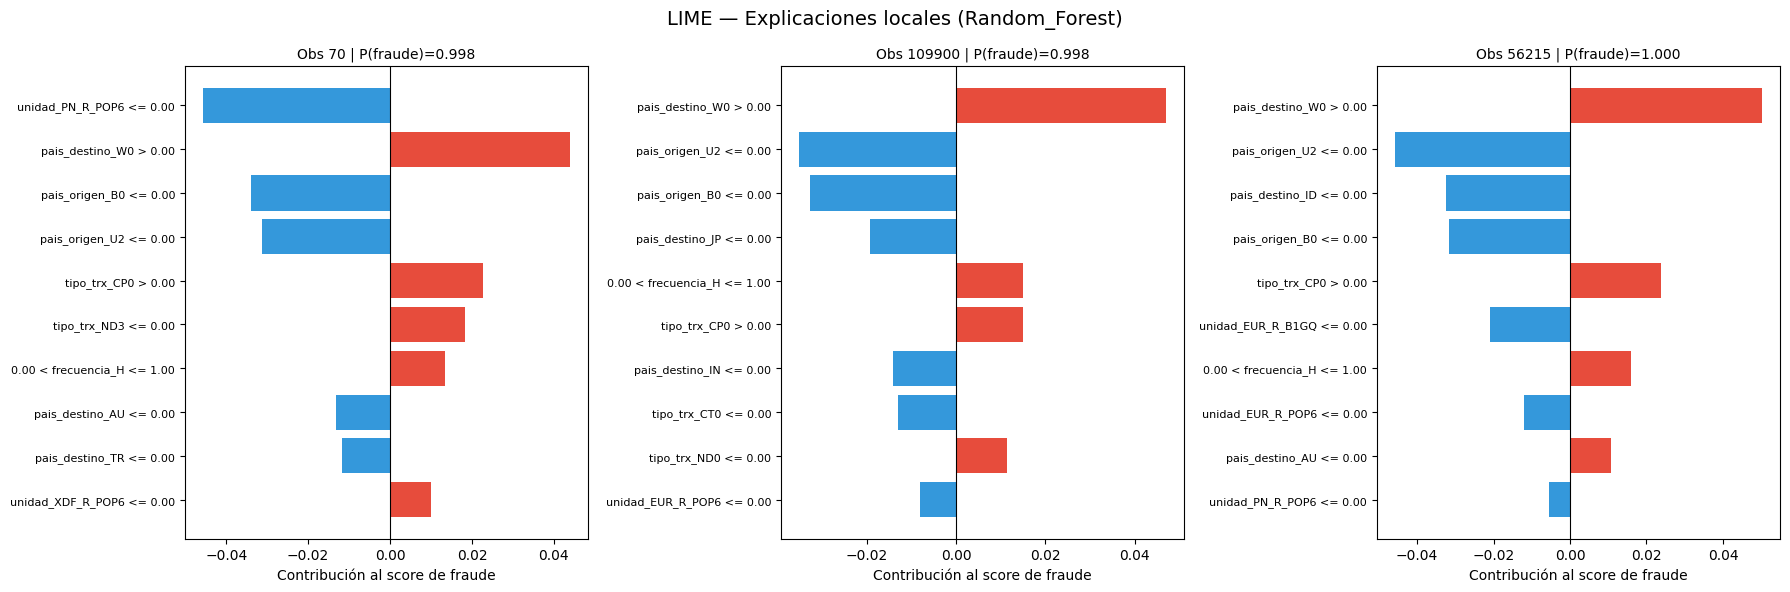

Guardado: models/lime_Random_Forest.png


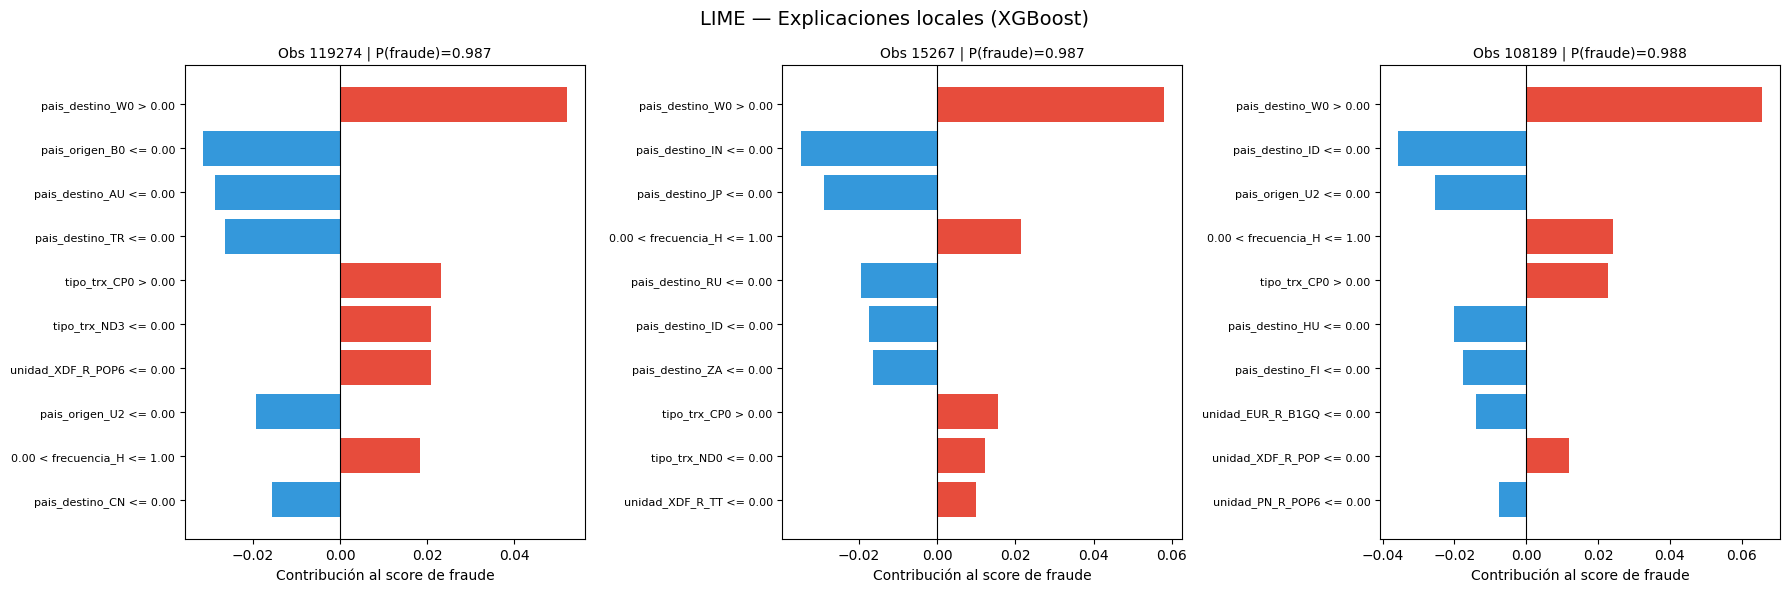

Guardado: models/lime_XGBoost.png


In [33]:
# ── LIME — Solo XGBoost y Random Forest ──────────────────
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

for nombre_modelo, modelo in [("Random_Forest", rf_model), ("XGBoost", xgb_model)]:

    preprocessor_fit = modelo.named_steps['preprocessor']
    classifier_fit   = modelo.named_steps['classifier']

    X_train_proc = preprocessor_fit.transform(X_train)
    X_test_proc  = preprocessor_fit.transform(X_test)

    num_features = ["monto_final"]
    ohe_features = preprocessor_fit.named_transformers_['cat']['onehot']\
                       .get_feature_names_out(FEATURES_CAT).tolist()
    feature_names = num_features + ohe_features

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data = X_train_proc,
        feature_names = feature_names,
        class_names   = ['Sin Fraude', 'Con Fraude'],
        mode          = 'classification',
        random_state  = RANDOM_STATE
    )

    y_prob = modelo.predict_proba(X_test)[:, 1]
    idx_fraudes = np.where(y_test == 1)[0]
    top3 = idx_fraudes[np.argsort(y_prob[idx_fraudes])[-3:]]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"LIME — Explicaciones locales ({nombre_modelo})", fontsize=14)

    for i, idx in enumerate(top3):
        exp = explainer.explain_instance(
            data_row  = X_test_proc[idx],
            predict_fn= classifier_fit.predict_proba,
            num_features = 10,
            labels    = (1,)
        )
        ax = axes[i]
        features_vals = exp.as_list(label=1)
        feat_names = [f[0] for f in features_vals]
        weights    = [f[1] for f in features_vals]
        colors     = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

        ax.barh(feat_names[::-1], weights[::-1], color=colors[::-1])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f"Obs {idx} | P(fraude)={y_prob[idx]:.3f}", fontsize=10)
        ax.set_xlabel("Contribución al score de fraude")
        ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig(f"models/lime_{nombre_modelo}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: models/lime_{nombre_modelo}.png")

En los 6 casos analizados (3 por modelo), emerge un patrón claro y repetido: pais_destino_W0 > 0 es la variable con mayor contribución positiva al score de fraude en prácticamente todas las observaciones, con contribuciones de hasta +0.05. Esto indica que transacciones dirigidas hacia ese destino geográfico específico son el predictor más fuerte de fraude que aprendieron ambos modelos de forma independiente, lo que le da alta credibilidad al hallazgo.
tipo_trx_CP0 > 0 aparece como segunda señal de fraude consistente en ambos modelos, junto con frecuencia_H (frecuencia horaria entre 0 y 1), sugiriendo que transacciones de ese tipo realizadas con baja frecuencia histórica son sospechosas. Por otro lado, pais_origen_U2, pais_origen_B0 y varios pais_destino específicos (AU, TR, IN, JP) aparecen en azul, actuando como factores protectores que reducen la probabilidad de fraude.  
Random Forest muestra explicaciones más dispersas entre variables de país, mientras XGBoost concentra más peso en pais_destino_W0 con contribuciones ligeramente mayores (+0.06 vs +0.05). Ambos modelos coinciden en las variables clave, lo que valida que el patrón aprendido es real y no un artefacto de un modelo específico. Las probabilidades predichas son todas superiores a 0.987, con Random Forest llegando a P=1.000 en un caso, reflejando casos de fraude con señales muy claras para ambos clasificadores.
Conclusión práctica: el fraude en este dataset está fuertemente asociado a combi

### Conclusión  

Este trabajo desarrolló un sistema de detección de fraude en transacciones financieras sobre un dataset de 657,943 registros con un desbalanceo extremo del 0.3% de casos positivos. Se evaluaron cinco modelos de clasificación (Regresión Logística, Naive Bayes, LinearSVC, XGBoost y Random Forest) bajo cuatro estrategias de balanceo (sin balanceo, SMOTE, ADASYN y pesos por clase), utilizando el PR-AUC como métrica principal por su sensibilidad ante clases desbalanceadas.  
El hallazgo más relevante del proceso de modelado fue que las técnicas de balanceo no mejoraron el rendimiento real en ningún modelo: SMOTE, ADASYN y class weights dispararon el recall hacia valores cercanos a 1.0, pero a costa de una precisión tan baja que haría inoperativo cualquier sistema de alertas en producción. La estrategia sin balanceo ganó consistentemente en PR-AUC test en todos los modelos, evidenciando que los datos contienen señal suficiente para que los modelos aprendan los patrones de fraude sin necesidad de intervención artificial sobre la distribución.  
Random Forest sin balanceo fue seleccionado como modelo final con un PR-AUC test de 0.9659 (IC Bootstrap 95%: [0.9537, 0.9761]), recall de 0.81 y precisión de 0.95, superando a XGBoost (0.9522) cuya diferencia en ROC-AUC resultó estadísticamente no significativa (p=0.922) pero sí observable en PR-AUC. Naive Bayes y LinearSVC quedaron descartados con PR-AUC de 0.1753 y 0.6844 respectivamente, diferencias estadísticamente significativas confirmadas por bootstrap (p=0.000).  
El análisis de explicabilidad con LIME reveló que el fraude está determinado principalmente por combinaciones de país de destino (especialmente pais_destino_W0) y tipo de transacción (tipo_trx_CP0), con la frecuencia horaria como señal secundaria, siendo el monto una variable de menor peso relativo. Este patrón fue consistente entre Random Forest y XGBoost de forma independiente, lo que otorga alta credibilidad al hallazgo y abre la posibilidad de implementar reglas geográficas complementarias como primera capa de detección rápida antes de invocar el modelo completo.